Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import nltk
from collections import Counter
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix,classification_report

Loading Dataset

In [2]:
df = pd.read_csv("spam.csv", encoding = 'latin-1')


In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


Data Preprocessing

In [6]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [7]:
df.rename(columns={'v1': 'Target','v2': 'Text'},inplace=True)
df.head()

,Target,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.isnull().sum()

,0
Target,0
Text,0


In [9]:

(df.duplicated().sum())
df = df.drop_duplicates(keep='first')

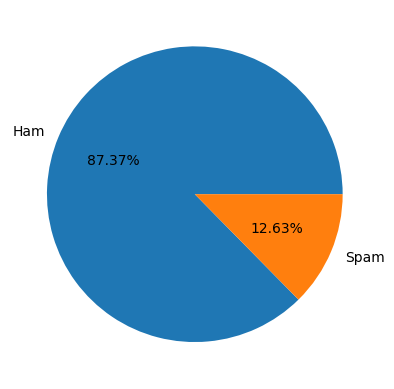

In [10]:
plt.pie(df['Target'].value_counts(),labels = ['Ham','Spam'],autopct="%0.2f%%")
plt.show()

In [12]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [13]:
df['num_character'] = df['Text'].apply(len)
df['num_words'] = df['Text'].apply(lambda x : len(nltk.word_tokenize(x)))
df['num_sentences'] = df['Text'].apply(lambda x : len(nltk.sent_tokenize(x)))
df.head()

,Target,Text,num_character,num_words,num_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [14]:
df[['num_character','num_words','num_sentences']].describe()

,num_character,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


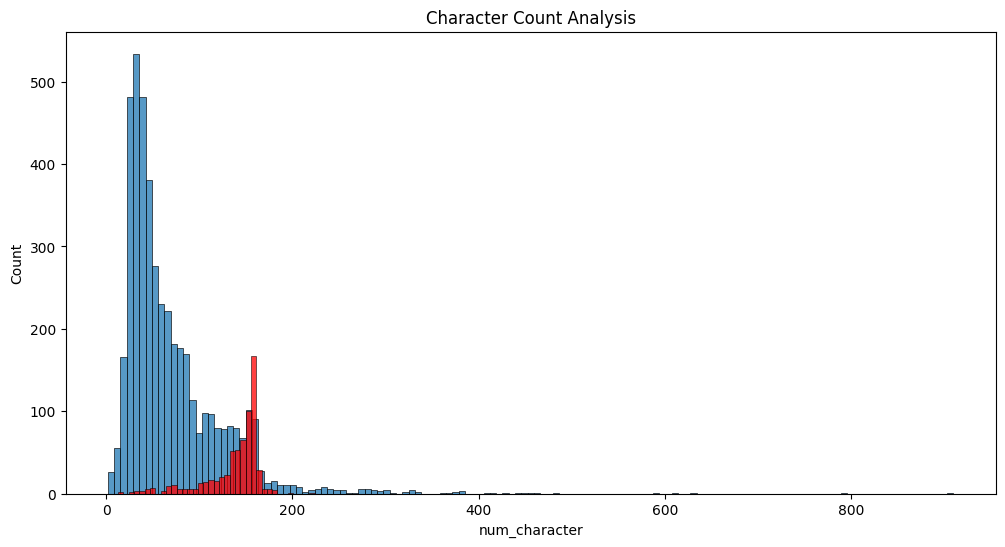

In [15]:
plt.figure(figsize=(12, 6))
sns.histplot(df[df['Target'] == 'ham' ]['num_character'])
sns.histplot(df[df['Target'] == 'spam' ]['num_character'],color='red')
plt.title("Character Count Analysis")
plt.show()

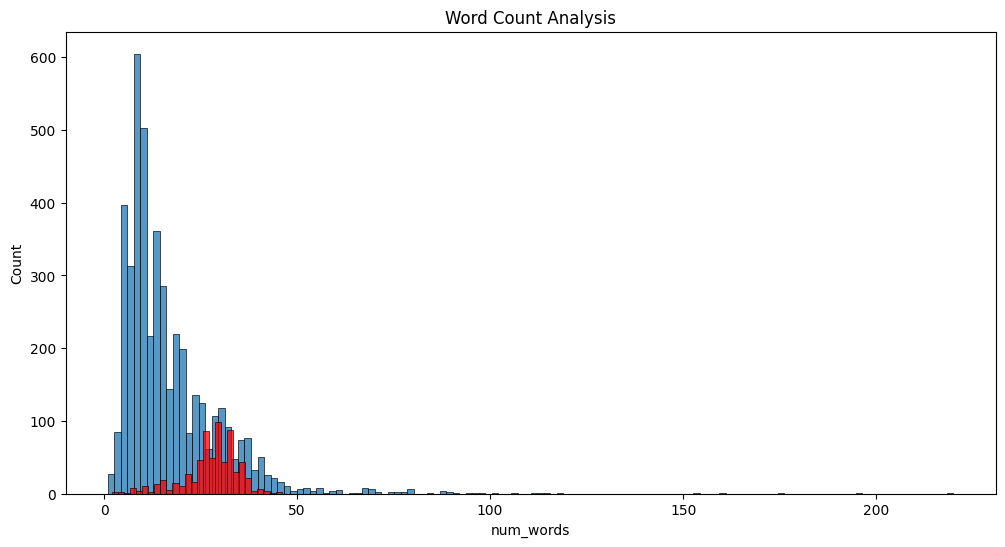

In [16]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['Target'] == 'ham']['num_words'])
sns.histplot(df[df['Target'] == 'spam']['num_words'],color='red')
plt.title("Word Count Analysis")
plt.show()

In [18]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [20]:
ps = PorterStemmer()

def clean_text(Text):
    Text = Text.lower()
    Text = nltk.word_tokenize(Text)

    y = []
    for word in Text:
        if word.isalnum():
            y.append(word)

    Text = y[:]
    y.clear()
    for word in Text:
        if word not in stopwords.words('english') and word not in string.punctuation:
            y.append(ps.stem(word))

    return " ".join(y)


df['cleaned_text'] = df['Text'].apply(clean_text)

df.head()

,Target,Text,num_character,num_words,num_sentences,cleaned_text
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


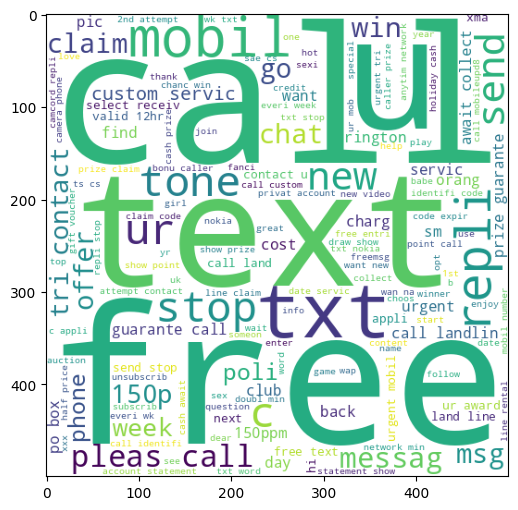

In [21]:
wc = WordCloud(width = 500, height = 500, min_font_size=10, background_color='white')
spam_wc = wc.generate(df[df['Target'] == 'spam' ]['cleaned_text'].str.cat(sep=" "))
plt.figure(figsize = (12,6))
plt.imshow(spam_wc)
plt.show()

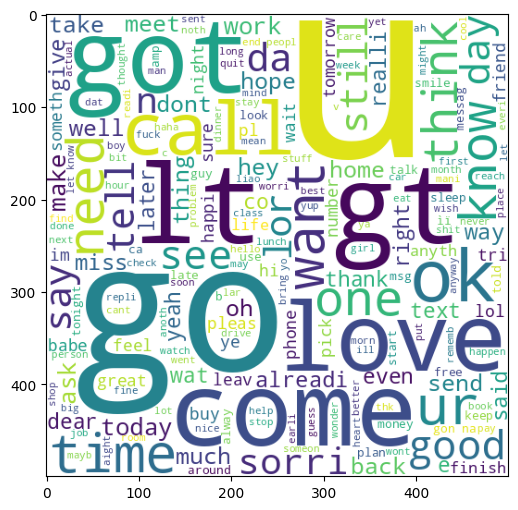

In [22]:
wc = WordCloud(width = 500, height = 500, min_font_size=10, background_color='white')
ham_wc = wc.generate(df[df['Target'] == 'ham' ]['cleaned_text'].str.cat(sep=" "))
plt.figure(figsize = (12,6))
plt.imshow(ham_wc)
plt.show()

In [23]:
spam_corpus = []
for msg in df[df['Target'] == 'spam']['cleaned_text'].tolist():
   for word in msg.split():
       spam_corpus.append(word)
print("Length of spam corpus",len(spam_corpus))

Length of spam corpus 9939


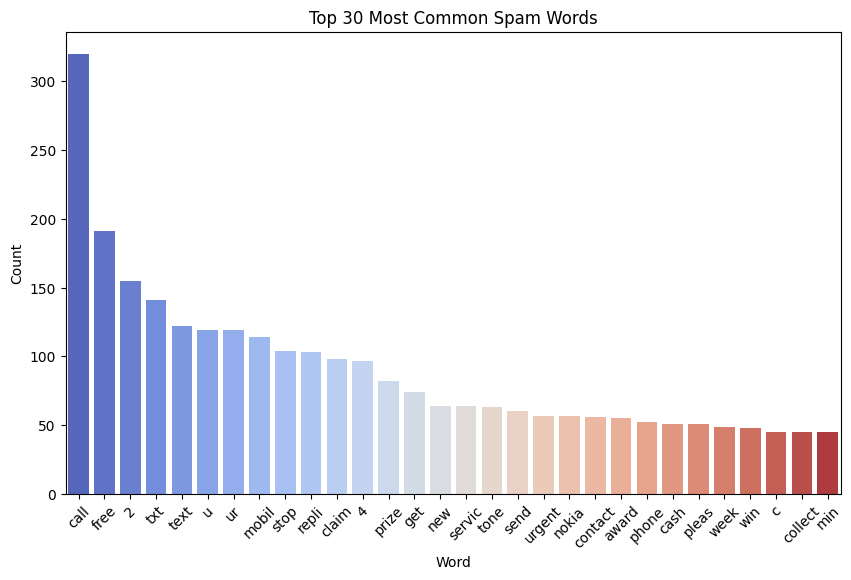

In [24]:
spam_df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['Word', 'Count'])

plt.figure(figsize=(10,6))
sns.barplot(x='Word', y='Count', data=spam_df, palette='coolwarm')
plt.xticks(rotation=45)
plt.title("Top 30 Most Common Spam Words")
plt.show()

In [25]:
ham_corpus = []
for msg in df[df['Target'] == 'ham']['cleaned_text'].tolist():
   for word in msg.split():
       ham_corpus.append(word)
print("Length of Ham corpus",len(ham_corpus))

Length of Ham corpus 35404


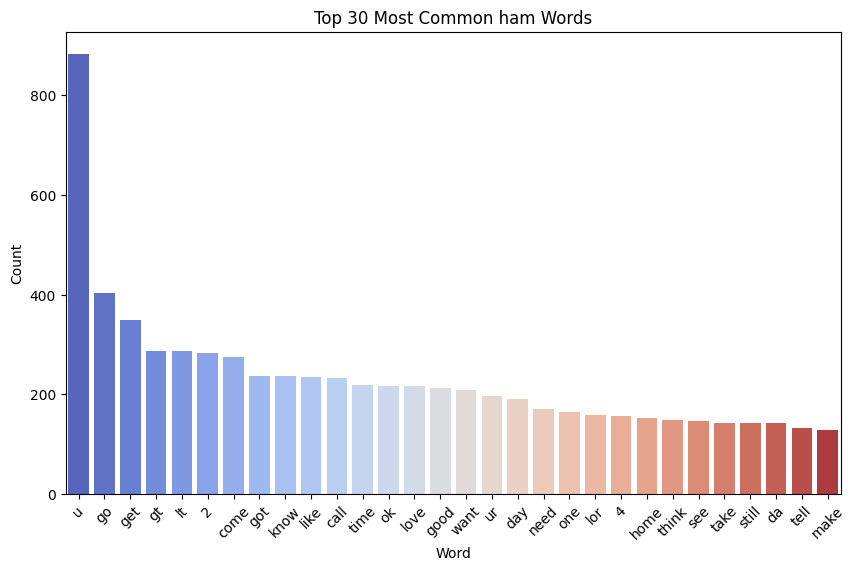

In [26]:
ham_df = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['Word', 'Count'])

plt.figure(figsize=(10,6))
sns.barplot(x='Word', y='Count', data=ham_df, palette='coolwarm')
plt.xticks(rotation=45)
plt.title("Top 30 Most Common ham Words")
plt.show()

Label Encoding

In [27]:
encoder = LabelEncoder()
df['Target'] = encoder.fit_transform(df['Target']) # ham = 0, spam = 1
tfidf = TfidfVectorizer(max_features=3000)# limit to top 3000 frequent words
X = tfidf.fit_transform(df['cleaned_text']).toarray()
X.shape

(5169, 3000)

In [28]:
y = df['Target'].values
y

array([0, 0, 1, ..., 0, 0, 0])

Train-Test-Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 2)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4135, 3000), (1034, 3000), (4135,), (1034,))

Model

In [30]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)

MultinomialNB()

In [31]:
y_pred = mnb.predict(X_test)

In [32]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("/nConfusion Matrix:", confusion_matrix(y_test,y_pred))
print("/nClassification Report:/n",classification_report(y_test,y_pred))
print("Precision Score:" , precision_score(y_test,y_pred))

Accuracy: 0.9709864603481625
/nConfusion Matrix: [[896   0]
 [ 30 108]]
/nClassification Report:/n               precision    recall  f1-score   support

           0       0.97      1.00      0.98       896
           1       1.00      0.78      0.88       138

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034

Precision Score: 1.0


In [33]:
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
0,0.967603,1.000000,0.983535,896.000000
1,1.000000,0.782609,0.878049,138.000000
accuracy,0.970986,0.970986,0.970986,0.970986
macro avg,0.983801,0.891304,0.930792,1034.000000
weighted avg,0.971926,0.970986,0.969456,1034.000000


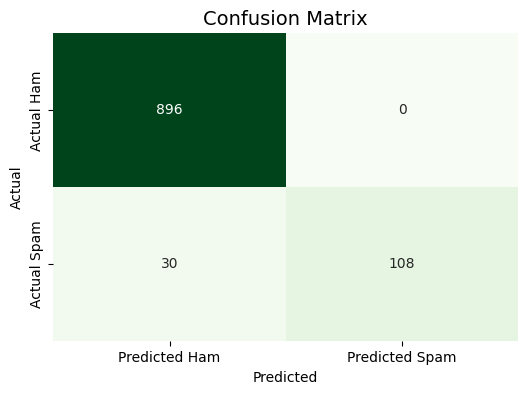

In [34]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Model Saving

In [35]:
import pickle
pickle.dump(mnb,open('spam_classifier.pkl','wb'))